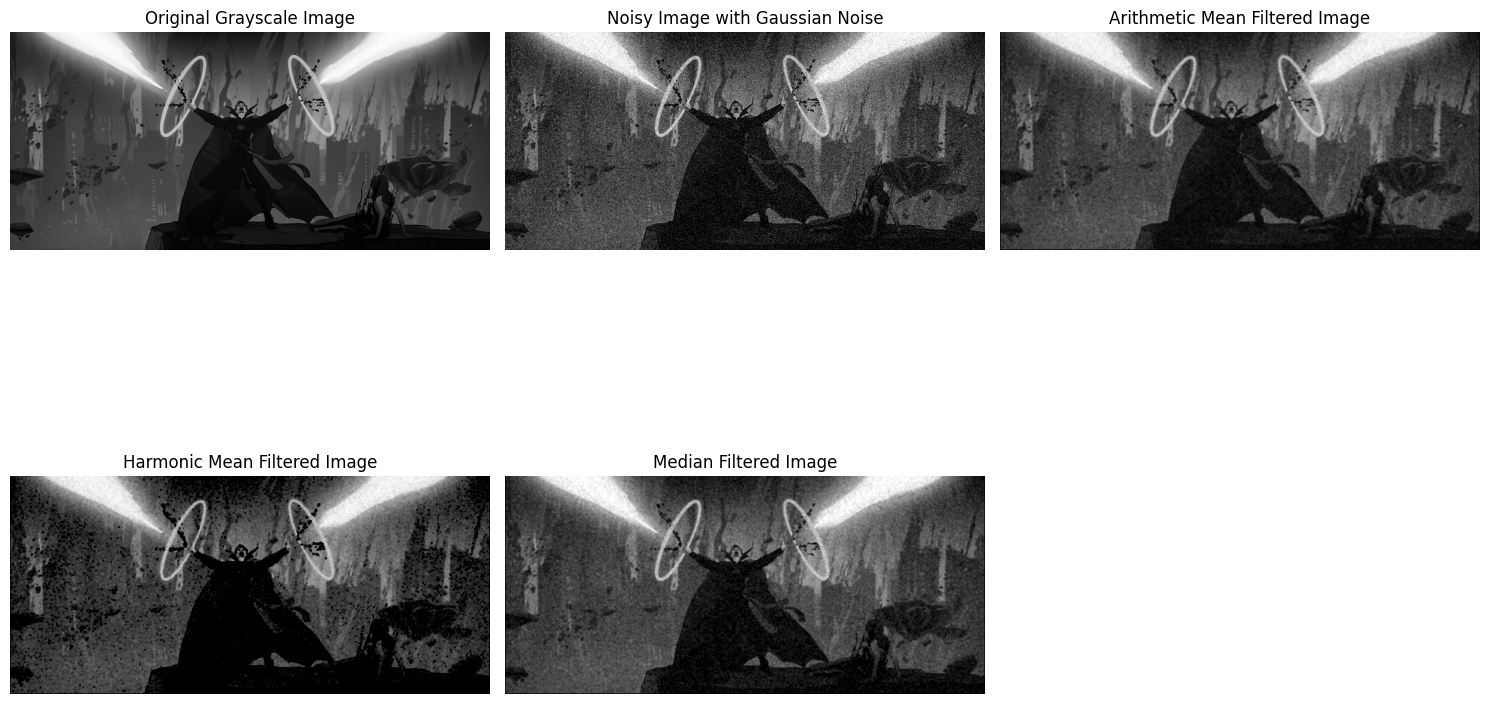

In [14]:
import cv2

import numpy as np

import matplotlib.pyplot as plt

# Function to add Gaussian noise to the image
def add_gaussian_noise_gray(image, mean=0, sigma=25):
    gaussian_noise = np.random.normal(mean, sigma, image.shape)
    noisy_image = np.clip(image + gaussian_noise, 0, 255).astype(np.uint8)
    return noisy_image

# Read the original image in grayscale
image = cv2.imread("doctor-strange-supreme.jpg", cv2.IMREAD_GRAYSCALE)

# Add Gaussian noise to the image
noisy_image = add_gaussian_noise_gray(image)

# Define kernel size (e.g., 3x3)
kernel_size = 3

# Arithmetic Mean Filter
height, width = noisy_image.shape
mean_filtered_image = np.zeros_like(noisy_image)

kernel_radius = kernel_size // 2

for x in range(kernel_radius, height - kernel_radius):
    for y in range(kernel_radius, width - kernel_radius):
        # Extract the neighborhood around the current pixel
        neighborhood = noisy_image[x - kernel_radius: x + kernel_radius + 1, y - kernel_radius: y + kernel_radius + 1]
        # Calculate the mean value of the neighborhood
        mean_value = np.mean(neighborhood)
        # Assign the mean value to the current pixel in the filtered image
        mean_filtered_image[x, y] = mean_value

# Harmonic Mean Filter
harmonic_filtered_image = np.zeros_like(noisy_image)

for x in range(kernel_radius, height - kernel_radius):
    for y in range(kernel_radius, width - kernel_radius):
        # Extract the neighborhood of the current pixel (x, y)
        neighborhood = noisy_image[x - kernel_radius: x + kernel_radius + 1, y - kernel_radius: y + kernel_radius + 1]
        # Calculate the harmonic mean of the neighborhood
        reciprocal_sum = np.sum(1.0 / (neighborhood + 1e-5))  # Add a small epsilon to avoid division by zero
        harmonic_mean_value = 9.0 / reciprocal_sum  # Assuming kernel size is 3x3
        # Assign the harmonic mean value to the current pixel in the filtered image
        harmonic_filtered_image[x, y] = harmonic_mean_value

# Median Filter
median_filtered_image = np.zeros_like(noisy_image)

for x in range(kernel_radius, height - kernel_radius):
    for y in range(kernel_radius, width - kernel_radius):
        # Extract the neighborhood of the current pixel (3x3)
        neighborhood = noisy_image[x - kernel_radius: x + kernel_radius + 1, y - kernel_radius: y + kernel_radius + 1]
        # Flatten the neighborhood and sort the pixel values
        flattened_neighborhood = neighborhood.flatten()
        flattened_neighborhood.sort()
        # Get the median value (middle value in the sorted list)
        median_value = flattened_neighborhood[len(flattened_neighborhood) // 2]
        # Assign the median value to the current pixel in the filtered image
        median_filtered_image[x, y] = median_value

# Display the images
plt.figure(figsize=(15, 10))

# Plot the original image
plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

# Plot the noisy image
plt.subplot(2, 3, 2)
plt.imshow(noisy_image, cmap='gray')
plt.title('Noisy Image with Gaussian Noise')
plt.axis('off')

# Plot the Arithmetic Mean Filtered image
plt.subplot(2, 3, 3)
plt.imshow(mean_filtered_image, cmap='gray')
plt.title('Arithmetic Mean Filtered Image')
plt.axis('off')

# Plot the Harmonic Mean Filtered image
plt.subplot(2, 3, 4)
plt.imshow(harmonic_filtered_image, cmap='gray')
plt.title('Harmonic Mean Filtered Image')
plt.axis('off')

# Plot the Median Filtered image
plt.subplot(2, 3, 5)
plt.imshow(median_filtered_image, cmap='gray')
plt.title('Median Filtered Image')
plt.axis('off')

# Show the plot
plt.tight_layout()
plt.show()


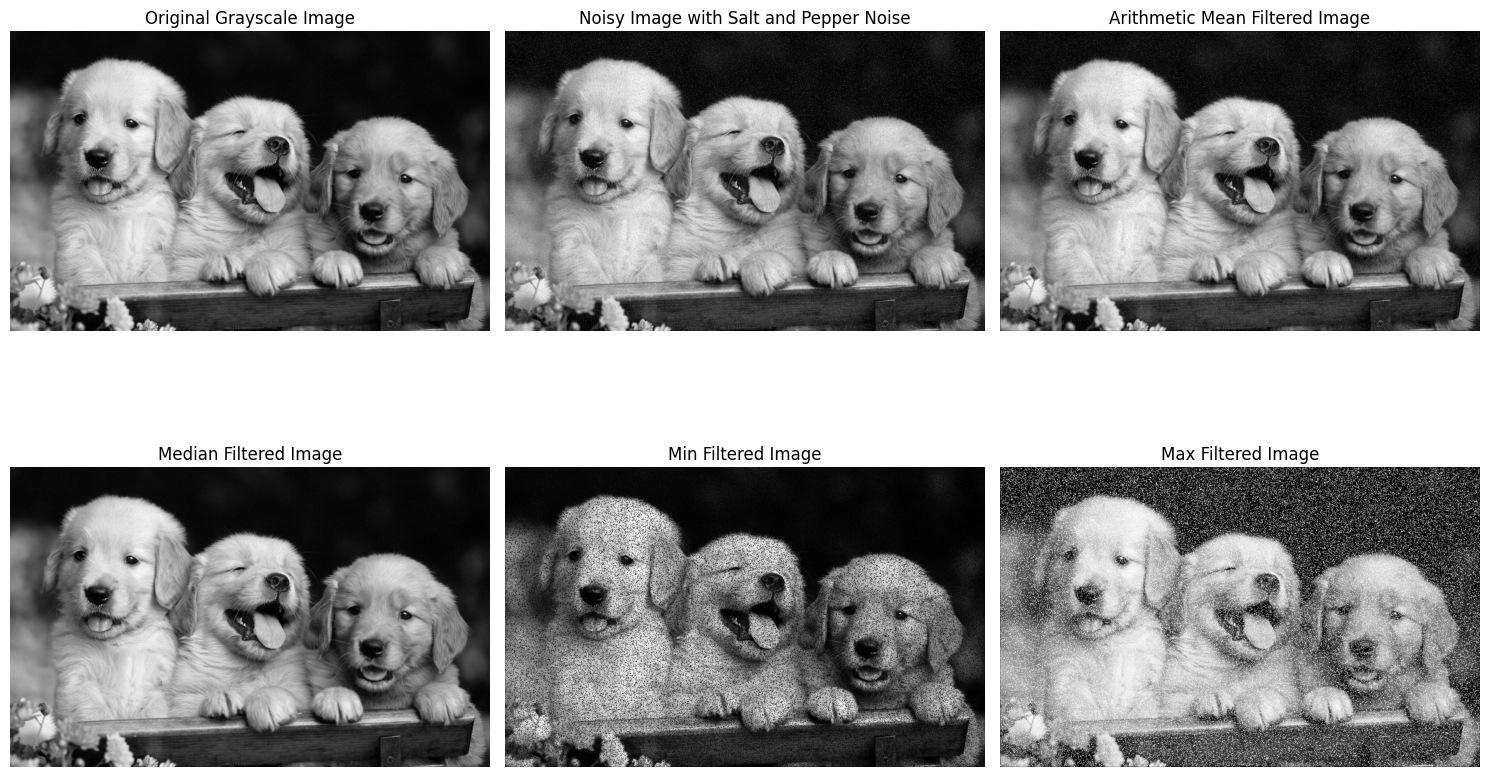

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter

# Function to add salt and pepper noise to the image
def salt_and_pepper_noise(image, prob):
    noisy_image = image.copy()
    total_pixels = image.size
    num_salt = int(prob * total_pixels)
    num_pepper = int(prob * total_pixels)

    salt_coords = [np.random.randint(0, i - 1, num_salt) for i in image.shape]
    noisy_image[salt_coords[0], salt_coords[1]] = 255

    pepper_coords = [np.random.randint(0, i - 1, num_pepper) for i in image.shape]
    noisy_image[pepper_coords[0], pepper_coords[1]] = 0

    return noisy_image

# Read the original image in grayscale
image = cv2.imread("dog2.jpg", cv2.IMREAD_GRAYSCALE)

# Add salt and pepper noise to the image
noisy_image = salt_and_pepper_noise(image, 0.02)

# Get the dimensions of the image
height, width = noisy_image.shape

# Define the kernel size (3x3, 5x5, etc.)
kernel_size = 3
kernel_radius = kernel_size // 2

# Create output images to store the filtered results
min_filtered_image = np.zeros_like(noisy_image)
max_filtered_image = np.zeros_like(noisy_image)
mean_filtered_image = np.zeros_like(noisy_image)

# Min and Max Filters
for x in range(kernel_radius, height - kernel_radius):
    for y in range(kernel_radius, width - kernel_radius):
        # Extract the kernel neighborhood (3x3 for example)
        neighborhood = noisy_image[x - kernel_radius: x + kernel_radius + 1, y - kernel_radius: y + kernel_radius + 1]
        
        # Apply Min Filter: Replace with the minimum value in the neighborhood
        min_filtered_image[x, y] = np.min(neighborhood)
        
        # Apply Max Filter: Replace with the maximum value in the neighborhood
        max_filtered_image[x, y] = np.max(neighborhood)

# Arithmetic Mean Filter
for x in range(kernel_radius, height - kernel_radius):
    for y in range(kernel_radius, width - kernel_radius):
        # Extract the neighborhood around the current pixel
        neighborhood = noisy_image[x - kernel_radius: x + kernel_radius + 1, y - kernel_radius: y + kernel_radius + 1]
        
        # Calculate the mean value of the neighborhood
        mean_value = np.mean(neighborhood)
        
        # Assign the mean value to the current pixel in the filtered image
        mean_filtered_image[x, y] = mean_value

# Apply Median Filter using scipy's median_filter
median_filtered_image = median_filter(noisy_image, size=kernel_size)

# Display the images
plt.figure(figsize=(15, 10))

# Plot the original image
plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

# Plot the noisy image
plt.subplot(2, 3, 2)
plt.imshow(noisy_image, cmap='gray')
plt.title('Noisy Image with Salt and Pepper Noise')
plt.axis('off')

# Plot the Arithmetic Mean Filtered image
plt.subplot(2, 3, 3)
plt.imshow(mean_filtered_image, cmap='gray')
plt.title('Arithmetic Mean Filtered Image')
plt.axis('off')

# Plot the Median Filtered image
plt.subplot(2, 3, 4)
plt.imshow(median_filtered_image, cmap='gray')
plt.title('Median Filtered Image')
plt.axis('off')

# Plot the Min Filtered image
plt.subplot(2, 3, 5)
plt.imshow(min_filtered_image, cmap='gray')
plt.title('Min Filtered Image')
plt.axis('off')

# Plot the Max Filtered image
plt.subplot(2, 3, 6)
plt.imshow(max_filtered_image, cmap='gray')
plt.title('Max Filtered Image')
plt.axis('off')

# Show the plot
plt.tight_layout()
plt.show()


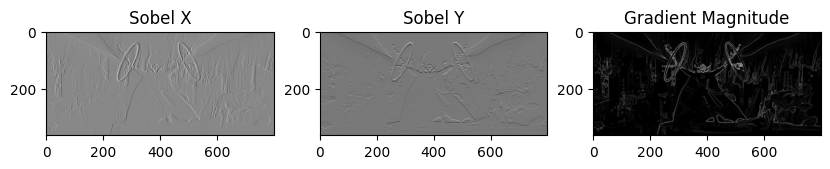

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def convolve(image, kernel):
    """Function to manually perform convolution between image and kernel."""
    # Get dimensions
    img_h, img_w = image.shape
    k_h, k_w = kernel.shape
    
    # Define output image with zero padding
    pad = k_h // 2
    output = np.zeros((img_h, img_w), dtype=np.float32)

    # Apply convolution
    for i in range(pad, img_h - pad):
        for j in range(pad, img_w - pad):
            # Extract region of interest
            region = image[i - pad:i + pad + 1, j - pad:j + pad + 1]
            # Convolve (element-wise multiplication and sum)
            output[i, j] = np.sum(region * kernel)

    return output

# Load image in grayscale

# Define Sobel kernels
sobel_x = np.array([[-1, 0, 1], 
                     [-2, 0, 2], 
                     [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1], 
                     [0,  0,  0], 
                     [1,  2,  1]])

# Apply convolution manually
grad_x = convolve(image, sobel_x)
grad_y = convolve(image, sobel_y)

# Compute gradient magnitude
gradient_magnitude = np.sqrt(grad_x**2 + grad_y**2)
gradient_magnitude = (gradient_magnitude / np.max(gradient_magnitude) * 255).astype(np.uint8)  # Normalize

# Display results
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1), plt.imshow(grad_x, cmap='gray'), plt.title('Sobel X')
plt.subplot(1, 3, 2), plt.imshow(grad_y, cmap='gray'), plt.title('Sobel Y')
plt.subplot(1, 3, 3), plt.imshow(gradient_magnitude, cmap='gray'), plt.title('Gradient Magnitude')
plt.show()
